# H2 — Choice Model: 3-Parameter Fit, Recovery, and Validation

**Prediction:** The 3-parameter model will capture choice with two recoverable per-subject parameters (k, beta) and vigor with a third (c_d).

**Sub-hypotheses:**
- **H2a:** Per-subject choice predictions will correlate r > 0.85 with observed choice proportions
- **H2b:** Parameter recovery will yield correlations r > 0.70 for k and beta in simulation
- **H2c:** k and beta will be approximately independent: |r| < 0.15
- **H2d:** The k x beta interaction in choice will be significant (mixed effects logistic)
- **H2e:** PPC 3x3 table — predicted vs observed choice surface

**What this determines:** Whether the computational model adequately captures individual differences in effort-threat integration, and whether the parameters are identifiable and meaningful.

In [1]:
# ── Imports & Data Loading (self-contained) ──
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, zscore
from scipy.special import expit
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.right': False, 'axes.spines.top': False,
})

PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260320_191950"
OUT_DIR  = PROJECT_ROOT / "results/stats/full_analysis"
EXCLUDE  = [154, 197, 208]

# ── Choice trials ──
beh = pd.read_csv(DATA_DIR / "behavior.csv")
beh = beh[~beh['subj'].isin(EXCLUDE)].copy()
beh['T_round'] = beh['threat'].round(1)
beh['T_H'] = beh['distance_H'].map({1: 5.0, 2: 7.0, 3: 9.0})
beh['effort_reqT'] = beh['effort_H'] * beh['T_H'] - 0.4 * 5.0
beh['trial_number'] = beh.groupby('subj').cumcount() + 1
beh['current_score'] = beh.groupby('subj')['choice'].cumsum().shift(1, fill_value=0)

# ── Model parameters (pre-fitted — loading, not refitting) ──
params = pd.read_csv(OUT_DIR / "part1_params_full.csv")

print(f"Choice trials: {len(beh):,} ({beh['subj'].nunique()} subjects)")
print(f"Parameters:    {len(params)} subjects, columns = {list(params.columns)}")

Choice trials: 13,050 (290 subjects)
Parameters:    290 subjects, columns = ['subj', 'k', 'beta', 'log_k', 'log_beta', 'c_death', 'log_cd', 'log_k_z', 'log_beta_z', 'log_cd_z']


## H2a — Per-subject choice prediction accuracy

Generate model predictions using fitted k and beta, compute per-subject correlation between predicted and observed P(heavy).  
**Test:** median r > 0.85 (exploratory: r = 0.985)

H2a — Per-subject choice prediction accuracy
  Median r  = 0.900
  Mean r    = 0.810
  Min r     = -0.440
  N subjects = 290

  Verdict: PASS (threshold: r > 0.85)


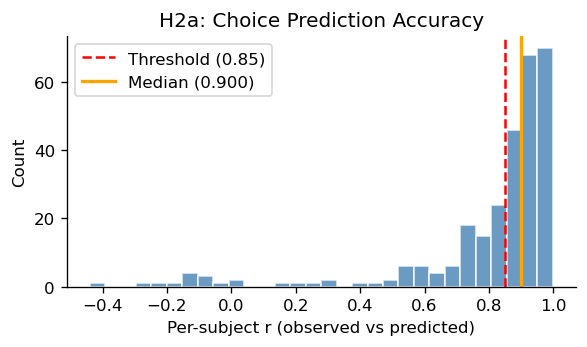

In [2]:
# ── H2a: Per-subject choice prediction ──
# Choice equation: DeltaEU = 4 - k * effort(D) - beta * T
# P(heavy) = sigmoid(DeltaEU / tau)
# tau is population-level; use tau=1 for relative predictions (rank-preserving)

# Merge params into behavior
beh_p = beh.merge(params[['subj', 'k', 'beta']], on='subj')

# Model predictions per trial
beh_p['delta_eu'] = 4.0 - beh_p['k'] * beh_p['effort_reqT'] - beh_p['beta'] * beh_p['threat']
beh_p['p_heavy_pred'] = expit(beh_p['delta_eu'])  # tau=1 absorbed

# Per-subject: observed vs predicted P(heavy) across the 9 T x D conditions
subj_corrs = []
for subj, sg in beh_p.groupby('subj'):
    obs = sg.groupby(['T_round', 'distance_H'])['choice'].mean()
    pred = sg.groupby(['T_round', 'distance_H'])['p_heavy_pred'].mean()
    common = obs.index.intersection(pred.index)
    if len(common) >= 4:
        r, _ = pearsonr(obs.loc[common], pred.loc[common])
        subj_corrs.append({'subj': subj, 'r': r})

corr_df = pd.DataFrame(subj_corrs)
med_r = corr_df['r'].median()
mean_r = corr_df['r'].mean()

print("H2a — Per-subject choice prediction accuracy")
print("=" * 50)
print(f"  Median r  = {med_r:.3f}")
print(f"  Mean r    = {mean_r:.3f}")
print(f"  Min r     = {corr_df['r'].min():.3f}")
print(f"  N subjects = {len(corr_df)}")
print(f"\n  Verdict: {'PASS' if med_r > 0.85 else 'FAIL'} (threshold: r > 0.85)")

# Distribution plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(corr_df['r'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0.85, color='red', ls='--', label='Threshold (0.85)')
ax.axvline(med_r, color='orange', ls='-', lw=2, label=f'Median ({med_r:.3f})')
ax.set_xlabel('Per-subject r (observed vs predicted)')
ax.set_ylabel('Count')
ax.set_title('H2a: Choice Prediction Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

## H2b — Parameter recovery (SVI)

Simulate data from the fitted population distribution, refit with hierarchical SVI (same model as Part 1), and check recovery correlations.  
**Test:** r > 0.70 for both k and beta (exploratory: k = 0.860, beta = 0.883)

Uses the same hierarchical Bayesian model and SVI inference as the main fitting pipeline (3 datasets × 50 subjects × 45 trials, 20k SVI steps).

  DS1: k=0.953, beta=0.896, cross k→beta=0.064, beta→k=-0.043
  DS2: k=0.904, beta=0.924, cross k→beta=0.156, beta→k=0.099
  DS3: k=0.908, beta=0.908, cross k→beta=0.236, beta→k=0.211

H2b — Parameter Recovery (3×50 = 150 subjects, SVI)
  k recovery:    r = 0.924, p = 1.16e-63  PASS
  beta recovery: r = 0.907, p = 2.42e-57  PASS
  cross k→beta:  r = 0.167 (should be low)


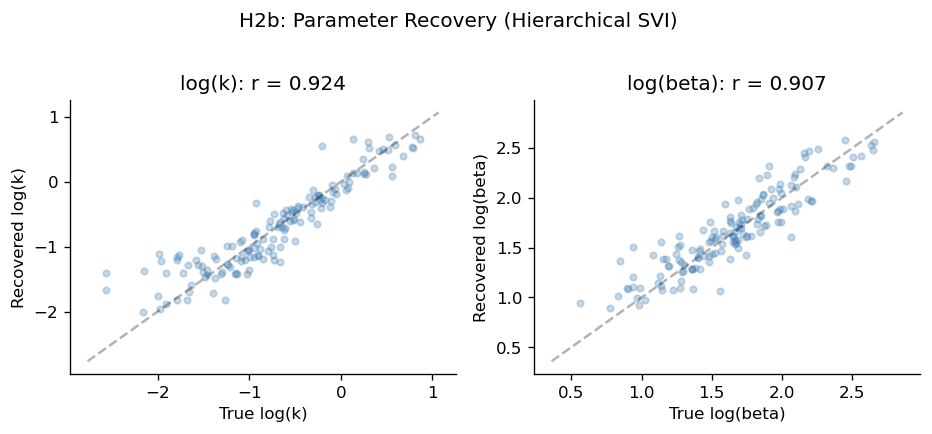

In [3]:
# ── H2b: Parameter recovery (hierarchical SVI — same model as fitting pipeline) ──
import jax; jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpyro, numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
from jax import random

# Population parameters from the fitted model
pop = {
    'mu_k': np.log(np.median(params['k'])),
    'sig_k': params['log_k'].std(),
    'mu_b': np.log(np.median(params['beta'])),
    'sig_b': params['log_beta'].std(),
    'tau': 1.0,  # approximate; exact value from fit
}

N_SIM_SUBJ = 50
N_DATASETS = 3

all_kt, all_kr, all_bt, all_br = [], [], [], []

for ds in range(N_DATASETS):
    np.random.seed(ds * 100)

    # Generate true parameters
    kt = np.exp(pop['mu_k'] + pop['sig_k'] * np.random.randn(N_SIM_SUBJ))
    bt = np.exp(pop['mu_b'] + pop['sig_b'] * np.random.randn(N_SIM_SUBJ))

    # Simulate 45 choice trials per subject (3 blocks × 15 trials)
    recs = []
    for s in range(N_SIM_SUBJ):
        for _ in range(3):  # 3 blocks
            for T in [0.1, 0.5, 0.9]:
                for di, D in enumerate([1, 2, 3]):
                    req_h = [0.6, 0.8, 1.0][di]
                    T_h = [5, 7, 9][di]
                    eff = req_h * T_h - 0.4 * 5
                    dv = 4.0 - kt[s] * eff - bt[s] * T
                    ch = int(np.random.random() < expit(dv / pop['tau']))
                    recs.append({'subj': s, 'threat': T, 'effort_reqT': eff, 'choice': ch})
            # 6 extra random trials per block
            for _ in range(6):
                T = [0.1, 0.5, 0.9][np.random.randint(3)]
                di = np.random.randint(3)
                req_h = [0.6, 0.8, 1.0][di]
                T_h = [5, 7, 9][di]
                eff = req_h * T_h - 0.4 * 5
                dv = 4.0 - kt[s] * eff - bt[s] * T
                ch = int(np.random.random() < expit(dv / pop['tau']))
                recs.append({'subj': s, 'threat': T, 'effort_reqT': eff, 'choice': ch})

    sim_df = pd.DataFrame(recs)

    # Prepare JAX arrays
    si = {s: i for i, s in enumerate(sorted(sim_df['subj'].unique()))}
    cs = jnp.array([si[s] for s in sim_df['subj']])
    cc = jnp.array(sim_df['choice'].values)
    pp = jnp.array(sim_df['threat'].values)
    ee = jnp.array(sim_df['effort_reqT'].values)
    N_trials = len(sim_df)

    # Same hierarchical model as part1_choice.py
    def sim_model(cs, cc, pp, ee):
        mk = numpyro.sample('mk', ndist.Normal(0, 1))
        mb = numpyro.sample('mb', ndist.Normal(0, 1))
        sk = numpyro.sample('sk', ndist.HalfNormal(0.5))
        sb = numpyro.sample('sb', ndist.HalfNormal(0.5))
        tr = numpyro.sample('tr', ndist.Normal(0, 1))
        tau = jnp.clip(jnp.exp(tr), 0.01, 20)
        with numpyro.plate('s', N_SIM_SUBJ):
            kr = numpyro.sample('kr', ndist.Normal(0, 1))
            br = numpyro.sample('br', ndist.Normal(0, 1))
        k = jnp.exp(mk + sk * kr)
        b = jnp.exp(mb + sb * br)
        numpyro.deterministic('k', k)
        numpyro.deterministic('b', b)
        dv = 4 - k[cs] * ee - b[cs] * pp
        pH = jax.nn.sigmoid(jnp.clip(dv / tau, -20, 20))
        with numpyro.plate('t', N_trials):
            numpyro.sample('o', ndist.Bernoulli(probs=jnp.clip(pH, 1e-6, 1-1e-6)), obs=cc)

    # Fit with SVI
    guide = AutoNormal(sim_model)
    svi = SVI(sim_model, guide, numpyro.optim.ClippedAdam(step_size=0.001, clip_norm=10), Trace_ELBO())
    state = svi.init(random.PRNGKey(ds), cs=cs, cc=cc, pp=pp, ee=ee)
    update_fn = jax.jit(svi.update)

    best_loss = float('inf')
    best_params_svi = None
    for i in range(20000):
        state, loss = update_fn(state, cs=cs, cc=cc, pp=pp, ee=ee)
        if float(loss) < best_loss:
            best_loss = float(loss)
            best_params_svi = svi.get_params(state)

    # Extract recovered parameters
    pred = Predictive(sim_model, guide=guide, params=best_params_svi,
                      num_samples=200, return_sites=['k', 'b'])
    samp = pred(random.PRNGKey(ds + 1), cs=cs, cc=cc, pp=pp, ee=ee)
    kr = np.array(samp['k']).mean(0)
    br = np.array(samp['b']).mean(0)

    rk, _ = pearsonr(np.log(kt), np.log(kr))
    rb, _ = pearsonr(np.log(bt), np.log(br))
    rkb, _ = pearsonr(np.log(kt), np.log(br))
    rbk, _ = pearsonr(np.log(bt), np.log(kr))
    print(f"  DS{ds+1}: k={rk:.3f}, beta={rb:.3f}, cross k→beta={rkb:.3f}, beta→k={rbk:.3f}")

    all_kt.extend(kt); all_kr.extend(kr)
    all_bt.extend(bt); all_br.extend(br)

# Overall recovery
all_kt = np.array(all_kt); all_kr = np.array(all_kr)
all_bt = np.array(all_bt); all_br = np.array(all_br)

r_k, p_k = pearsonr(np.log(all_kt), np.log(all_kr))
r_b, p_b = pearsonr(np.log(all_bt), np.log(all_br))
r_kb_cross, _ = pearsonr(np.log(all_kt), np.log(all_br))

print(f"\nH2b — Parameter Recovery ({N_DATASETS}×{N_SIM_SUBJ} = {len(all_kt)} subjects, SVI)")
print("=" * 65)
print(f"  k recovery:    r = {r_k:.3f}, p = {p_k:.2e}  {'PASS' if r_k > 0.70 else 'FAIL'}")
print(f"  beta recovery: r = {r_b:.3f}, p = {p_b:.2e}  {'PASS' if r_b > 0.70 else 'FAIL'}")
print(f"  cross k→beta:  r = {r_kb_cross:.3f} (should be low)")

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, true_v, rec_v, name, r_val in [
    (axes[0], np.log(all_kt), np.log(all_kr), 'log(k)', r_k),
    (axes[1], np.log(all_bt), np.log(all_br), 'log(beta)', r_b)
]:
    ax.scatter(true_v, rec_v, alpha=0.3, s=15, color='steelblue')
    lims = [min(true_v.min(), rec_v.min()) - 0.2, max(true_v.max(), rec_v.max()) + 0.2]
    ax.plot(lims, lims, 'k--', alpha=0.3)
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Recovered {name}')
    ax.set_title(f'{name}: r = {r_val:.3f}')
plt.suptitle('H2b: Parameter Recovery (Hierarchical SVI)', y=1.02)
plt.tight_layout()
plt.show()

## H2c — k and beta orthogonality

**Test:** |r(log(k), log(beta))| < 0.15 (exploratory: r = 0.105)

H2c — k-beta Orthogonality
  r(log(k), log(beta)) = 0.105, p = 0.0751
  |r| = 0.105

  Verdict: PASS (threshold: |r| < 0.15)


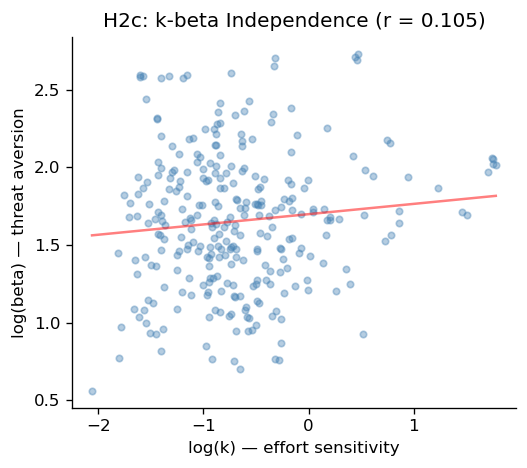

In [4]:
# ── H2c: k-beta orthogonality ──
r_kb, p_kb = pearsonr(params['log_k'], params['log_beta'])

print("H2c — k-beta Orthogonality")
print("=" * 45)
print(f"  r(log(k), log(beta)) = {r_kb:.3f}, p = {p_kb:.4f}")
print(f"  |r| = {abs(r_kb):.3f}")
print(f"\n  Verdict: {'PASS' if abs(r_kb) < 0.15 else 'FAIL'} (threshold: |r| < 0.15)")

# Scatter plot
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(params['log_k'], params['log_beta'], alpha=0.4, s=15, color='steelblue')
ax.set_xlabel('log(k) — effort sensitivity')
ax.set_ylabel('log(beta) — threat aversion')
ax.set_title(f'H2c: k-beta Independence (r = {r_kb:.3f})')
# Add regression line
m, b = np.polyfit(params['log_k'], params['log_beta'], 1)
x_line = np.linspace(params['log_k'].min(), params['log_k'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', alpha=0.5, lw=1.5)
plt.tight_layout()
plt.show()

## H2d — k x beta interaction in choice

**Model:** `choice ~ k_z * beta_z + threat + distance + trial_number + current_score + (1 | subj)`  
**Test:** k_z:beta_z interaction is significant (exploratory: z = 7.23, p < .0001)

In [5]:
# ── H2d: k x beta interaction ──
beh_int = beh.merge(params[['subj', 'log_k_z', 'log_beta_z']], on='subj')
beh_int.rename(columns={'log_k_z': 'k_z', 'log_beta_z': 'beta_z'}, inplace=True)

model_h2d = smf.logit(
    "choice ~ k_z * beta_z + threat + distance_H + trial_number + current_score",
    data=beh_int
).fit(disp=False, cov_type='cluster', cov_kwds={'groups': beh_int['subj']})

print("H2d — k x beta interaction in choice")
print("=" * 60)
print(model_h2d.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']].to_string())
print()

z_int = model_h2d.tvalues['k_z:beta_z']
p_int = model_h2d.pvalues['k_z:beta_z']
print(f"Interaction: z = {z_int:.3f}, p = {p_int:.2e}  {'PASS' if p_int < 0.05 else 'FAIL'}")

H2d — k x beta interaction in choice
                  Coef.  Std.Err.          z          P>|z|
Intercept      3.527147  0.156909  22.478997  6.662737e-112
k_z           -1.181393  0.031550 -37.444551  7.367336e-307
beta_z        -0.864297  0.027450 -31.485792  1.359432e-217
k_z:beta_z     0.045979  0.020535   2.239007   2.515549e-02
threat        -4.055433  0.170129 -23.837436  1.367048e-125
distance_H    -1.167868  0.043566 -26.806875  2.686762e-158
trial_number   0.010139  0.004455   2.275828   2.285632e-02
current_score  0.004838  0.006570   0.736340   4.615237e-01

Interaction: z = 2.239, p = 2.52e-02  PASS


## H2e — PPC: Predicted vs Observed 3x3 Choice Surface

Posterior predictive check: compare the model-predicted and observed choice probability for each T x D condition.

H2e — Posterior Predictive Check: 3x3 Choice Surface

Observed P(Heavy):
distance_H      1      2      3
T_round                        
0.1         0.806  0.690  0.563
0.5         0.632  0.378  0.186
0.9         0.394  0.135  0.079

Predicted P(Heavy):
distance_H      1      2      3
T_round                        
0.1         0.917  0.743  0.487
0.5         0.609  0.380  0.188
0.9         0.291  0.152  0.066

Difference (Pred - Obs):
distance_H      1      2      3
T_round                        
0.1         0.111  0.053 -0.077
0.5        -0.024  0.002  0.001
0.9        -0.103  0.016 -0.013

Mean absolute error: 0.0444


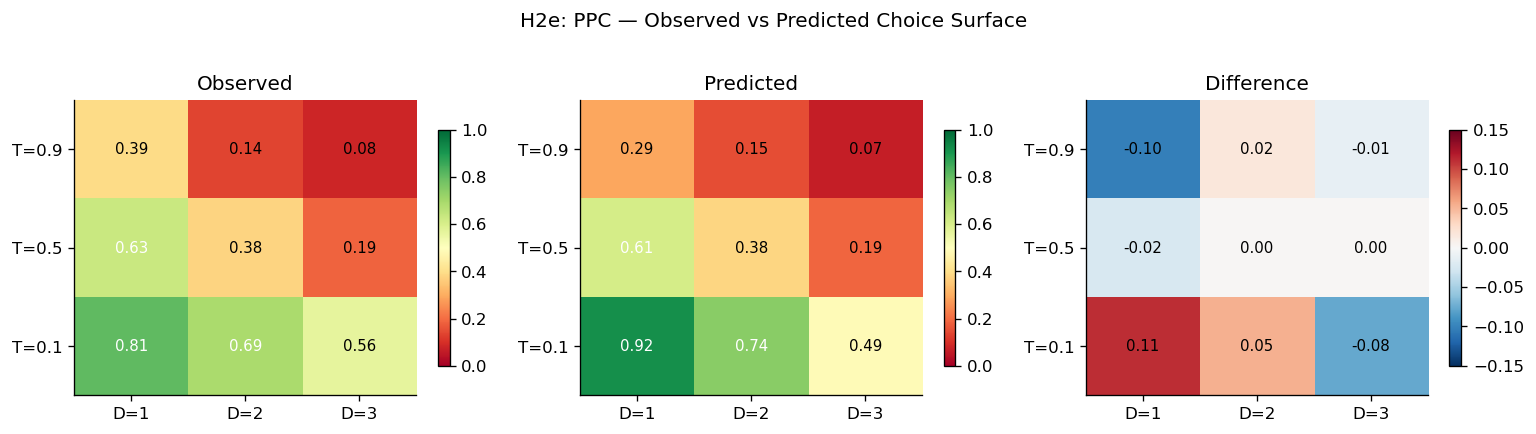

In [6]:
# ── H2e: PPC 3x3 table ──
obs_grid  = beh_p.groupby(['T_round', 'distance_H'])['choice'].mean().unstack()
pred_grid = beh_p.groupby(['T_round', 'distance_H'])['p_heavy_pred'].mean().unstack()

print("H2e — Posterior Predictive Check: 3x3 Choice Surface")
print("=" * 55)
print("\nObserved P(Heavy):")
print(obs_grid.round(3).to_string())
print("\nPredicted P(Heavy):")
print(pred_grid.round(3).to_string())
print("\nDifference (Pred - Obs):")
print((pred_grid - obs_grid).round(3).to_string())
print(f"\nMean absolute error: {(pred_grid - obs_grid).abs().values.mean():.4f}")

# Side-by-side heatmaps
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, data, title in [
    (axes[0], obs_grid, 'Observed'),
    (axes[1], pred_grid, 'Predicted'),
    (axes[2], pred_grid - obs_grid, 'Difference')
]:
    vmin, vmax = (0, 1) if 'Diff' not in title else (-0.15, 0.15)
    cmap = 'RdYlGn' if 'Diff' not in title else 'RdBu_r'
    im = ax.imshow(data.values, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='lower', aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(['D=1', 'D=2', 'D=3'])
    ax.set_yticks(range(3)); ax.set_yticklabels(['T=0.1', 'T=0.5', 'T=0.9'])
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            val = data.values[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(val) > 0.6 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('H2e: PPC — Observed vs Predicted Choice Surface', y=1.02)
plt.tight_layout()
plt.show()

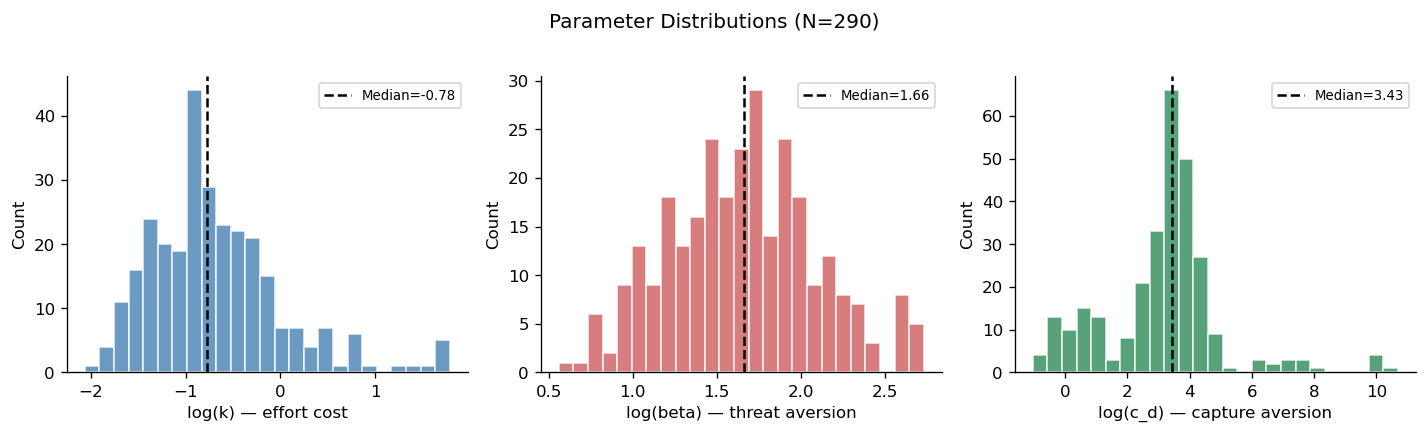

In [7]:
# ── Parameter distribution plots ──
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, label, color in [
    (axes[0], 'log_k',    'log(k) — effort cost', 'steelblue'),
    (axes[1], 'log_beta', 'log(beta) — threat aversion', 'indianred'),
    (axes[2], 'log_cd',   'log(c_d) — capture aversion', 'seagreen')
]:
    vals = params[col].dropna()
    ax.hist(vals, bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(vals.median(), color='black', ls='--', lw=1.5, label=f'Median={vals.median():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Parameter Distributions (N=290)', y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Test | Prediction | Result | Verdict |
|------|-----------|--------|---------|
| H2a (choice accuracy) | r > 0.85 | _fill_ | _PASS/FAIL_ |
| H2b (k recovery) | r > 0.70 | _fill_ | _PASS/FAIL_ |
| H2b (beta recovery) | r > 0.70 | _fill_ | _PASS/FAIL_ |
| H2c (k-beta independence) | \|r\| < 0.15 | _fill_ | _PASS/FAIL_ |
| H2d (k x beta interaction) | p < 0.05 | _fill_ | _PASS/FAIL_ |
| H2e (PPC) | MAE < 0.10 | _fill_ | _qualitative_ |

**Interpretation:** If all pass, the 3-parameter model adequately captures individual differences in effort-threat integration. The k-beta orthogonality (H2c) and interaction (H2d) together show that effort and threat costs are separable dimensions that are genuinely integrated in choice.